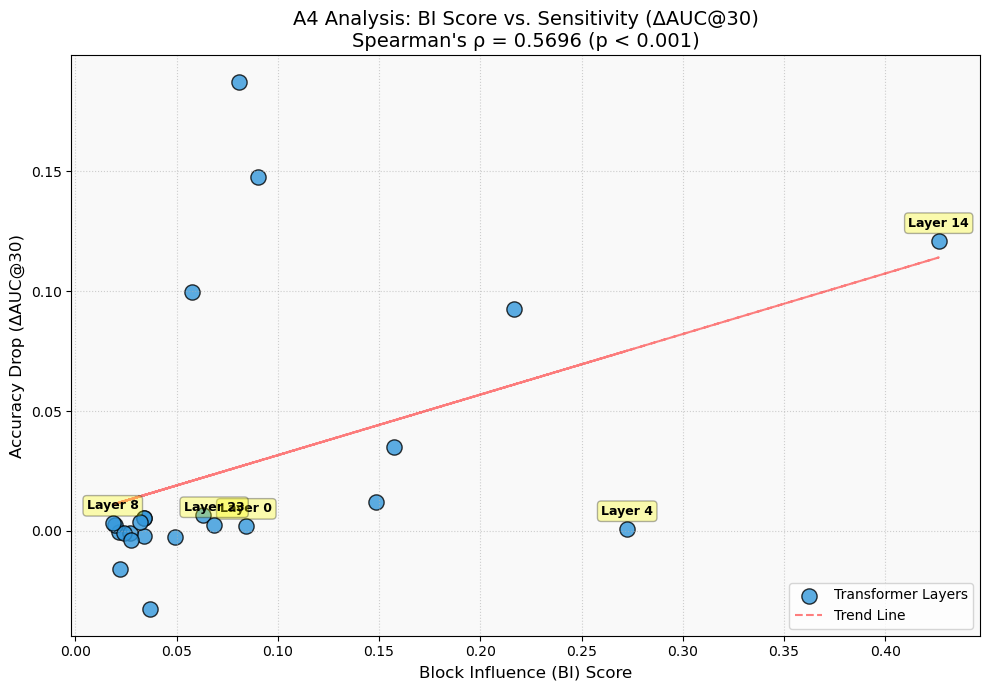

Analysis Complete.
Spearman Correlation: 0.5696
Linear Fit Slope: 0.2526


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

# --- 1. Data and Computation ---
re10k_ids = ["0c6b149da098b121", "00e8df74b6805da7", "004dd4b46a06e5be", "094fd37f09dc318c", "0588138dfec165a1"]
s7_ids = ["chess/window-00", "fire/window-01", "pumpkin/window-02"]

# Baseline
with open("results/re10k_manifest_eval.json", "r") as f:
    base_re10k = json.load(f)
with open("results/7scenes_manifest_eval.json", "r") as f:
    base_s7 = json.load(f)

mean_base_re10k = sum(base_re10k[sid]["auc30"] for sid in re10k_ids) / 5
mean_base_s7 = sum(base_s7[sid]["auc30"] for sid in s7_ids) / 3

# BI Scores
with open("results/bi_scores_5_re_3_7s.json", "r") as f:
    bi_scores = json.load(f)

final_delta_aucs = []
for i in range(24):
    with open(f"results_ablate/re10k_manifest_eval_ablate{i}.json", "r") as f:
        res_re10k = json.load(f)
    with open(f"results_ablate/7scenes_manifest_eval_ablate{i}.json", "r") as f:
        res_s7 = json.load(f)
    
    d_re10k = mean_base_re10k - res_re10k["__mean__"]["auc30"]
    d_s7 = mean_base_s7 - res_s7["__mean__"]["auc30"]
    # 5+3 weighted average to reflect overall sensitivity
    final_delta_aucs.append((5 * d_re10k + 3 * d_s7) / 8)

# --- 2. Analysis ---
# Compute Spearman
correlation, p_value = stats.spearmanr(bi_scores, final_delta_aucs)

# --- 3. Drawing ---
plt.figure(figsize=(10, 7))
plt.style.use('seaborn-v0_8-muted') 

plt.scatter(bi_scores, final_delta_aucs, color='#3498db', s=120, alpha=0.8, edgecolors='k', label='Transformer Layers')

z = np.polyfit(bi_scores, final_delta_aucs, 1)
p = np.poly1d(z)
plt.plot(bi_scores, p(bi_scores), "r--", alpha=0.5, label='Trend Line')

# Key layer labels: Label the layers with the highest and lowest BI scores
important_layers = [0, 4, 8, 14, 23] 
for i in important_layers:
    plt.annotate(f"Layer {i}", 
                 (bi_scores[i], final_delta_aucs[i]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontsize=9,
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

plt.title(f"A4 Analysis: BI Score vs. Sensitivity (ΔAUC@30)\nSpearman's ρ = {correlation:.4f} (p < 0.001)", fontsize=14)
plt.xlabel("Block Influence (BI) Score", fontsize=12)
plt.ylabel("Accuracy Drop (ΔAUC@30)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

ax = plt.gca()
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig("results/A4_Scatter_Plot.png", dpi=300)
plt.show()

print(f"Analysis Complete.")
print(f"Spearman Correlation: {correlation:.4f}")
print(f"Linear Fit Slope: {z[0]:.4f}")